In [1]:
from pyDOE import *
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import pandas as pd
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math 
from tqdm import trange
from torch.autograd import grad
from data_generator import Schrodinger_Boundary, Schrodinger_Initial, Schrodinger

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Torch utilizing dev",device)

Torch utilizing dev cpu


# Training data

In [2]:
boundary = Schrodinger_Boundary(num_col_bound = 50)
initial = Schrodinger_Initial(num_h_init = 50)
schrodinger = Schrodinger(num_col_schro = 20000)

schrodinger_dl = DataLoader(schrodinger, batch_size=4096, shuffle=True)

c:\Users\Lorenz\Masterthesis\Git\ZnPINNLab\day2\data_generator.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(h_func(self.x)).float().to(device),


# Data preperation

In [3]:
def create_training_data(
        boundary_vals, 
        initial_vals, 
        schrodinger_vals,
        num_col_train = 20000
    ):
    """
    Create training and test data for training procedure.

    This function generates training and test datasets using a subset
    of the boundary values , initial values and the schrodinger values.
    Therefore the following steps need to be done:
    

    Step 1: Data Point Selection
            Select evenly spaced values from the 'schrodinger_vals' tensor:

            - Create a tensor 'all_idx' containing indices between 0 
              and len(schrodinger_vals)-1 to select data points.
            - Create a tensor 'idx_train' containing 'num_t_train'evenly spaced indices 
              between 0 and the length of the 'schrodinger_vals' tensor to select data points.
            - Generate a mask with booleans of len(all_idx) that gives False statements for entries
              that are both in 'all_idx' and in 'idx_train'.
            - Build a tensor 'idx_test' by applying the mask on 'all_idx'.
            - Ensure that the data type of all idx tensors are integer.

    Step 2: Training Data Creation
            - Define 'schrodinger_train'tensor by selecting index values 'idx_train' 
              from 'schrodinger_vals' and 'position_vals'.
            - We don't want to make changes to the original data therefore use '.clone().detach()'.
        
    Step 3: Testing Data Creation
            Repeat the procedure of step to by selecting index values 'idx_test'.

    Step 4: Dataset Creation
            - Create datasets train_ds and test_ds by using dictionaries 
              containing "boundary", "initial", "schrodinger" and "t_col"(if already defined) entries.
            - Use the getall method in order to extract tensors for the "boundary" and "initial" keys.
              
        
    Step 5:  Return the created datasets.
    
    Parameters
    ----------
    boundary_vals : torch.Tensor
        A tensor containing boundary values.
    initial_vals : torch.Tensor
        A tensor containing initial values.
    schrodinger_vals : torch.Tensor
        A tensor containing Schrödinger values.
    num_t_col : int, optional
        The number of evenly spaced time values to generate in 't_col'. Default is 100.
        
    Returns
    -------
    Dict
        A dictionary containing "boundary," "initial," and "schrodinger" entries for training data.
    Dict
        A dictionary containing "boundary," "initial," and "schrodinger" entries for testing data.
    """
    
    # Step 1: Create a tensors of indices that correspond to the selected time values.
    all_idx = torch.arange(0, len(schrodinger_vals)-1, dtype=torch.int)
    idx_train = torch.linspace(0, len(schrodinger_vals)-1, num_col_train, dtype=torch.int)
    mask = ~torch.isin(all_idx, idx_train)
    idx_test = all_idx[mask]
    
    # Step 2: - Get t_train, x_train and y_train by selecting values from the provided data.
    schrodinger_train = schrodinger_vals[idx_train].clone().detach()

    # Step 3: Get t_test, x_test, y_test from the provided data
    schrodinger_test = schrodinger_vals[idx_test].clone().detach()

    
    # Step 5: Create datasets train_ds and test_ds by using dictionaries 
    train_ds = {"boundary": boundary_vals.getall(), "initial": initial_vals.getall(),"schrodinger": schrodinger_train}
    test_ds = {"boundary": boundary_vals.getall(), "initial": initial_vals.getall(),"schrodinger": schrodinger_test}

    # Step 6: return datasets
    return train_ds, test_ds


In [4]:
train_ds, test_ds = create_training_data(boundary, initial, schrodinger)
X, T, H = train_ds["initial"]
print(X.shape)

torch.Size([50, 1])


# Train PINN on Non-Linear Schrodinger's Equation

$ih_{t} + 0.5h_{xx} + h|h|^{2}= 0$ 

Boundary conditions

*   $h(t,5)=h(t,-5)$ 

*   $h_{x}(t,5)=h_{x}(-t,5)$

Regularization


* $f(x,t) = ih_{t} + 0.5h_{xx} + h|h|^{2}= 0$ 
 

Neural network approximates $h(x,t)$ with real-numbered u,v outputs representing the real and complex parts respectively. MSE for complex & real parts are calculated separately without use of PyTorch complex numbers



Trained over 20,000 epochs at lr=0.0025 using CUDA

# Create PINN model

In [5]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network (PINN) Class
    
    This class as a subclass of torch.nn.Module defines the architecture of the PINN model. 
    It is designed to use differential equations while incorporating physics-based constraints.
    The process consists of the following steps:
    
    Step 1: Model Initialization
        - Initialize the PINN model as a subclass of nn.Module.

    Step 2: Constructor Definition
        - Build a constructor to configure the model's architecture.
        - Utilize the nn.Linear class from the PyTorch library for defining layers and connections.

    Step 3: Forward Pass Mechanism
        - Define the forward pass mechanism for the model, where input data flows through the layers
          to produce predicted outputs.
       
    """
    def __init__(self):
        """
        Constructor for the PINN class.
        
        Initializes the layers of the neural network:
        - Input layer fc1 taking a tensor with time and space data.
        - Four hidden fully connected layers fc2-fc5 with 100 neurons.
        - Output layer h_real for predicting the real part.
        - Output layer h_imag for predicting the imaginary part.
        
        Parameters
        ----------
        None
            
        Attributes
        ----------
        fc1 : nn.Linear
            First fully connected layer.
        fc2 : nn.Linear
            Second fully connected layer.
        fc3 : nn.Linear
            Third fully connected layer.
        fc4 : nn.Linear
            Fourth fully connected layer.
        fc5 : nn.Linear
            Fifth fully connected layer.
        h_real : nn.Linear
            Output layer for x-coordinate prediction.
        h_imag : nn.Linear
            Output layer for y-coordinate prediction.
        
        Returns
        -------
        None
        
        """
        super(PINN, self).__init__()
        
        # Step 2: Configure model architecture as described earlier
        self.fc1 = nn.Linear(2,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        self.fc2 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        self.fc3 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        self.fc4 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        self.fc5 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc5.weight)
        self.h_real = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_real.weight)
        self.h_imag = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_imag.weight)
        self.optimizer = optim.Adam(self.parameters(), lr=0.00025)
        pass
    
    def forward(self, x):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data X is processed through the layers to produce predicted
        outputs for both real part of the solution (h_real) 
        and imaginary part of the solution (h_imag).
        The following steps are necessary:
        
    1. Pass input through layers with GELU Activation:
        - Pass the input tensor 'X' through the 'fc1' linear layer.
        - Apply the tanh activation function 'torch.tanh' to the output.
        - reply this procedure for the remaining layers

    2. Output Layer for Predicted Coordinates:
        - Compute the predicted real solution by passing the transformed tensor 'x' 
          through the 'h_real' layer.
        - Compute the predicted imaginary solutiun by passing the same transformed tensor 'x' 
          through the 'h_imag' layer.
        
        Parameters
        ----------
        t : torch.Tensor
            Input data tensor.
            
        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Predicted real and imaginary solution.
        """

        # Step 1: Apply the tanh activation on each fully connected layer.
        x = torch.tanh(self.fc1(x))   
        x = torch.tanh(self.fc2(x))  
        x = torch.tanh(self.fc3(x))  
        x = torch.tanh(self.fc4(x))  
        x = torch.tanh(self.fc5(x))     

        # Step 2: Produce predicted real and imaginary solution using output layers and return them. 
        h_real = self.h_real(x)
        h_imag = self.h_imag(x)

        return h_real, h_imag

# Boundary loss

In [6]:
def compute_boundary_loss(model, dataset: dict):
    """
    Define the physics-informed loss for the PINN model.
    
    This function calculates the loss used to incorporate the boundary conditions
    into the PINN. The following steps are involved:
    
    Step 1: Data Preparation
        - Unpack 'boundary' from the dataset and enable gradient computation.
        - Create a tensor 'fives' containing the value 5 with the same length as 't_bound'.

    Step 2: Model Prediction
        - Predict real and imaginary values at (5, t_bound) and (-5, t_bound) using the neural network model.
        - Concatenate the two input tensors along axis 1.

    Step 3: Gradient Computation
        - Compute the first gradients 'hp_r_x', 'hp_c_x', 'hn_r_x', and 'hn_c_x' 
          with respect to the 'fives' tensor using the 'torch.autograd.grad' method.

    Step 4: Difference Calculation
        - Calculate the difference between 'hp_r' and 'hn_r' for real and imaginary parts.
        - Use 'torch.unsqueeze' to add a dimension along the 1 axis.

    Step 5: Derivative Difference Calculation
        - Calculate the difference between 'hp_r_x' and 'hn_r_x' for real and imaginary parts.
        - This time no 'torch.unsqueeze' needed

    Step 6: Error Calculation
        - Define 'h_err' and 'h_x_err' by adding the squared differences of real and imaginary parts.

    Step 7: Loss Calculation
        - Compute the mean squared error loss for 'h_err' and 'h_x_err' using the 'nn.MSELoss' class.
        - as a target serves a tensor containing zeros. It can be produced using 'torch.zeros_like'
        - Return the combined physics-informed loss as the sum of 'loss_h' and 'loss_h_x'.
    
    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "boundary" entries.
        
    Returns
    -------
    torch.Tensor
        The combined (h and h_x) physics-informed loss.
    """
    # Step 1: Data Preparation
    t_bound = dataset["boundary"]
    t_bound.requires_grad = True

    fives = torch.ones((len(t_bound),1), requires_grad=True).to(device)*5.
    
    # Step 2: Model Prediction
    hp_r, hp_c = model(torch.cat((fives,t_bound),1))
    hn_r, hn_c = model(torch.cat((-fives,t_bound),1))
    
    # Step 3: Gradient Computation
    hp_r_x = grad(outputs=hp_r, inputs=fives, grad_outputs=torch.ones_like(hp_r), create_graph=True)[0]
    hp_c_x = grad(outputs=hp_c, inputs=fives, grad_outputs=torch.ones_like(hp_c), create_graph=True)[0]

    hn_r_x = grad(outputs=hn_r, inputs=fives, grad_outputs=torch.ones_like(hn_r), create_graph=True)[0]
    hn_c_x = grad(outputs=hn_c, inputs=fives, grad_outputs=torch.ones_like(hn_c), create_graph=True)[0]
    
    # Step 4: Difference Calculation
    h_r_diff = torch.unsqueeze(hp_r - hn_r, 1)
    h_c_diff = torch.unsqueeze(hp_c - hn_c, 1)

    # Step 5: Derivative Difference Calculation
    h_xr_diff = hp_r_x - hn_r_x
    h_xc_diff = hp_c_x - hn_c_x

    # Step 6: Error Calculation

    h_err = h_r_diff**2 + h_c_diff**2
    h_x_err = h_xr_diff**2 + h_xc_diff**2

    # Step 7: Loss Calculation
    mse_loss = nn.MSELoss()

    loss_h = mse_loss(h_err, torch.zeros_like(h_err))
    loss_h_x = mse_loss(h_x_err, torch.zeros_like(h_x_err))

    return loss_h + loss_h_x


# Initial loss

In [7]:
def compute_initial_loss(model, dataset: dict):
    """
    Calculate the loss associated with satisfying the initial conditions for the PINN model.

    This function computes the loss that measures how well the initial conditions are met by the PINN. 
    The dataset containes information about the initial condition: h(x,0) = 2*sech(x).
    The following steps are involved:

    Step 1: Data Preparation
        - Extract 'X_0', 'T_0', and 'H_0' from the training dataset and enable gradient computation.

    Step 2: Model Prediction
        - Use the neural network model to predict the real and imaginary values at (X_0, T_0).
        - Concatenate the two input tensors along axis 1.

    Step 3: Concatenation
        - Combine the real and imaginary parts of the predicted values along axis 1.

    Step 4: Loss Calculation
        - Calculate and return the mean squared error loss between 'H_0' and the concatenated values 'h'.

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    train_ds : dict
        A dictionary that includes "initial" entries with "X_0," "T_0," and "H_0."

    Returns
    -------
    torch.Tensor
        The loss quantifying how well the initial conditions are satisfied.
    """
    # Step 1: Data Preparation
    X_0, T_0 ,H_0 = dataset["initial"]
    X_0.requires_grad = True
    T_0.requires_grad = True
    H_0.requires_grad = True

    zeros = torch.zeros((len(X_0),1)).float().to(device)
    # Step 2: Model Prediction
    h_r, h_c = model(torch.cat((X_0, T_0),1))

    # Step 3: Concatenation
    h = torch.cat((h_r, h_c), 1)
    
    # Step 4: Loss Calculation
    mse_loss = nn.MSELoss()
    loss_h_0 = mse_loss(H_0, h)

    return loss_h_0

# Physics informed loss

In [8]:
def compute_physics_informed_loss(model, dataset: dict):
    """
    Calculate the loss for the Schrödinger equation condition in the PINN model.

    This function computes the loss that measures how well the Schrödinger equation condition
    is satisfied by the PINN. The following steps are involved:

    Step 1: Data Preparation
        - Extract the tensor 'X' from the training dataset in "schrodinger" and enable gradient computation.

    Step 2: Tensor Extraction
        - Extract two tensors 'x' and 't' from 'X,' representing the first and second columns of 'X.'
        - Ensure that 'x' and 't' have a shape of (len(X), 1).

    Step 3: Model Prediction
        - Use the neural network model to predict the real and imaginary values at (x, t).
        - Concatenate the two input tensors along axis 1.

    Step 4: Derivative Computation
        - Compute the second derivatives with respect to 'x' and the first derivatives with respect to 't' 
          for both the real and the imaginary part of the solution.

    Step 5: Residuals Definition
        - Define residuals 'f_r' and 'f_i' containing the Schrödinger equation condition: 
          ih_t + 0.5h_xx + h(|h|^2) = 0.

    Step 6: Residual Calculation
        - Define a residual 'f' by computing the Euclidean norm from 'f_r' and 'f_i.'

    Step 7: Loss Calculation
        - Calculate and return the mean squared error loss between 'f' and zeros.

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    train_ds : dict
        A dictionary containing "schrodinger" entries.
        
    Returns
    -------
    torch.Tensor
        The loss quantifying how well the Schrödinger equation condition is satisfied.
    """
    # Step 1: Data Preparation
    X = dataset["schrodinger"]
    X.requires_grad = True

    # Step 2: Tensor Extraction
    x = torch.unsqueeze(X[:,0], 1)
    t = torch.unsqueeze(X[:,1], 1)

    # Step 3: Model Prediction
    hf_r, hf_c = model(torch.cat((x,t),1))

    # Step 4: Derivative Computation
    h_f_x_r = grad(outputs=hf_r, inputs=x, grad_outputs=torch.ones_like(hf_r), create_graph=True)[0]
    h_f_xx_r = grad(outputs=h_f_x_r, inputs=x, grad_outputs=torch.ones_like(h_f_x_r), create_graph=True)[0]
    h_f_t_r = grad(outputs=hf_r, inputs=t, grad_outputs=torch.ones_like(hf_r), create_graph=True)[0]
    
    h_f_x_c = grad(outputs=hf_c, inputs=x, grad_outputs=torch.ones_like(hf_c), create_graph=True)[0]
    h_f_xx_c = grad(outputs=h_f_x_c, inputs=x, grad_outputs=torch.ones_like(h_f_x_c), create_graph=True)[0]
    h_f_t_c = grad(outputs=hf_c, inputs=t, grad_outputs=torch.ones_like(hf_c), create_graph=True)[0]

    # Step 5: Residuals Definition
    f_r = (h_f_t_r) + (0.5 * h_f_xx_c) + (((hf_r**2)+(hf_c**2))*hf_c)   
    f_i = (h_f_t_c) - (0.5 * h_f_xx_r) - (((hf_r**2)+(hf_c**2))*hf_r) 

    # Step 6: Residual Calculation
    f = torch.sqrt((f_r**2) + (f_i**2))

    # Step 7: Loss Calculation
    mse_loss = nn.MSELoss()
    loss_f = mse_loss(f, torch.zeros_like(f))
    
    return loss_f

# Total loss

In [9]:
def compute_total_loss(model, dataset: dict):
    """
    Define the total loss for the physics-informed neural network.

    This function computes the total loss for the PINN model by combining three
    different components:  boundary, inital and physics-informed loss.
    The following steps are involved:

    Step 1: Loss Calculation
        - Determine the boundary, inital and physics loss using the corresponding functions.

    Step 2: Total Loss Combination
        - Return the combined total loss as the sum of 'data_loss' and 'physics_loss' (if activated).


    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "inputs", "targets_x", "targets_y", and "t_col" entries.

    Returns
    -------
    torch.Tensor
        The combined total loss considering data and physics constraints.
    """
    # Step 1: Loss Calculation
    initial_loss = compute_initial_loss(model, dataset)
    boundary_loss = compute_boundary_loss(model, dataset)
    physics_loss = compute_physics_informed_loss(model, dataset)

    # Step 3: Total Loss Combination
    total_loss = initial_loss + boundary_loss + physics_loss

    return total_loss


# Executive funtion

In [10]:
def execute(
        model,
        train_ds: dict,
        test_ds: dict,
        lr = 0.00025, 
        num_epochs = 25000,
    ):
    """
    Execute the training procedure for a physics-informed neural network model.

    This function trains the model using specified hyperparameters and returns relevant data.
    The process involves the following steps:
    
    Step 1: Optimizer Initialization
            The optimizer is used to update the model's parameters during training. Therefore:
            - Initialize the optimizer, Adam with the model parameters.
            - Configure it with a specified learning rate 'lr'.
            More informations on the Adam optimizer can be found here:
            (see [ADAM](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
        
    Step 2: Lists Initialization
            In order to store the values of the models loss during the training process:
            - Initialize the lists 'train_loss_evolution' and 'test_loss_evolution'. 

    Step 3: Training Loop Setup
            Set up a training loop that will run for a specified number of epochs ('num_epochs'). 
            An epoch is one complete pass through the entire training dataset.

    Inside the training loop:

        Step 4: Gradient Reset
                In preparation for a fresh gradient computation, reset the gradient of the optimizer to zero. 
                Achieve this through by invoking the 'zero_grad' method on the optimizer.
                (see[zero_grad](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html))

        Step 5: Loss Calculation
                Calculate the 'train_loss' and 'test_loss' using the 'compute_total_loss' function.
                Make sure,
                - the 'train_loss' takes the 'activate_physics' information is taken from the methods parameters
                - the 'test_loss' is calculated with 'activate_physics' set to False. 

        Step 6: Training Step
                - Calculate the gradients of the model's parameters with respect to the total loss.
                  Do so by applying the 'backward' method on the train_loss. More information on this method here:
                  (see[backward](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html))
                - Then invoke the 'step' method on the optimizer in order to update the model parameters.
                  This Update is based on the calculated gradients beforehand. 
                  (see[step](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.step.html))

        Step 7: Loss Tracking
                - For later analysis, append the current train and test loss values to the appropriated lists.

    Step 8: Data Return
            Once the training loop is completed, return the lists you have initialized in Step 2.

    Parameters
    ----------
    model : torch.nn.Module
        The neural network model to be trained and evaluated.
    train_ds : dict
        A dictionary containing training data, including inputs and targets.
    test_ds : dict
        A dictionary containing test data, including inputs and targets.
    lr : float, optional
        Learning rate for the optimizer. Default is 0.005.
    num_epochs : int, optional
        Number of training epochs. Default is 1000.

    Returns
    -------
    list
        A list containing train loss values during training.
    list
        A list containing test loss values during training
    """    
    
    # Step 1: Optimizer Initialization
    optimizer = optim.Adam(model.parameters(), lr=lr,)  # Include weight_decay in the optimizer
    
    # Step 2: Lists Initialization
    train_loss_evolution = []
    test_loss_evolution = []


    # Define Loading Bar
    loading_bar = trange(1, num_epochs + 1)
    
    # Step 3: Training Loop Setup
    for epoch in loading_bar:
        
        # Step 4: Gradient Reset
        optimizer.zero_grad()
        
        # Step 5: Loss Calculation
        train_loss = compute_total_loss(model, train_ds)
        test_loss = compute_total_loss(model, test_ds)
        
        
        # Step 6 Training Step
        train_loss.backward()
        optimizer.step()


        # Step 7: Loss Tracking
        train_loss_evolution.append(float(train_loss))
        test_loss_evolution.append(float(test_loss))


        # Print current epoch and losses
        loading_bar.set_description(f"Epoch: {epoch}")
        loading_bar.set_postfix({"Test Loss": test_loss.item(), "Train Loss": train_loss.item()})
            
    
    # Step 8: Data Return
    return train_loss_evolution, test_loss_evolution

# Execution Task: Verification
Execute Training and Visualize  
    Execute the training for the following set of (hyper)parameters.  
    Plot the loss evolution during training and the final prediction of the model (after training).
    Compare the final predictions to the true solution of the trajectory. 
        
- Use __10000 collocation training points__ for data generation
- Train over __20 epochs__ $n_\text{epochs} = 300$



In [11]:
# Step 1: Initialize the model by calling the PINN class created earlier.
model = PINN()

# Step 2: Generate training and test datasets by calling the 'create_training_data' function.
train_ds, test_ds = create_training_data(boundary, 
        initial, 
        schrodinger,
        num_col_train = 10000)
# Step 3: Execute the training and testing of the model.
train_loss_evolution, test_loss_evolution = execute(
    model,
    test_ds=test_ds,
    train_ds=train_ds,
    num_epochs=25
)

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 25: 100%|██████████| 25/25 [00:15<00:00,  1.58it/s, Test Loss=0.173, Train Loss=0.173]


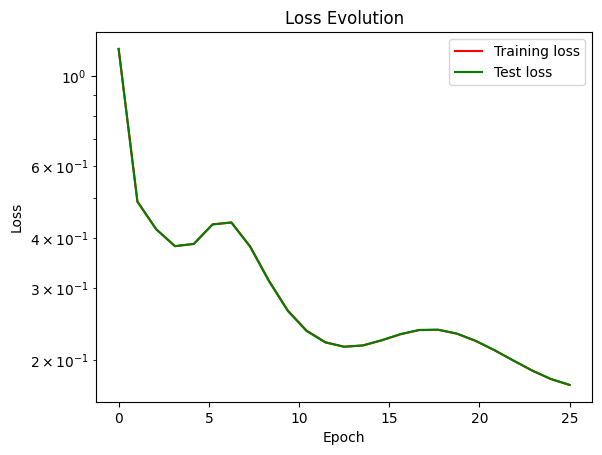

In [12]:
# Generate x values (angle values)
x = np.linspace(0, 2 * np.pi, 1000)  # Generate 1000 data points from 0 to 2*pi

# Compute the sine values for the corresponding x values
y = np.sin(x)

# Create a figure and axis
fig, ax = plt.subplots()

# Add labels and a legend
ax.plot(np.linspace(0, len(train_loss_evolution), len(train_loss_evolution)), train_loss_evolution, c='r', label='Training loss')
ax.plot(np.linspace(0, len(test_loss_evolution), len(test_loss_evolution)), test_loss_evolution, c='g', label='Test loss')
ax.legend()
ax.set_title('Loss Evolution')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')  # Set y-axis to logarithmic scale

# Show the plot
plt.show()

# Plot results & approximated solution



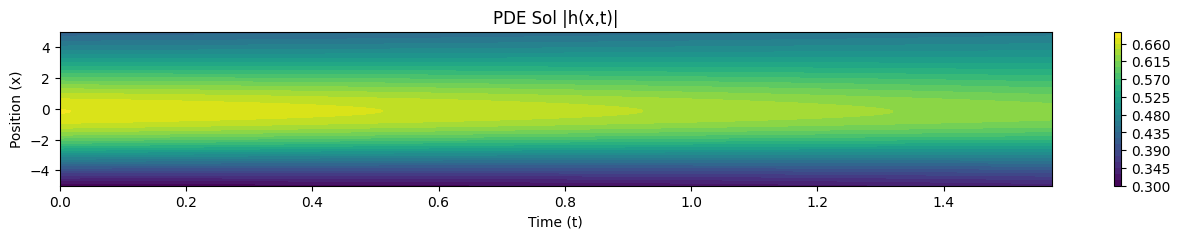

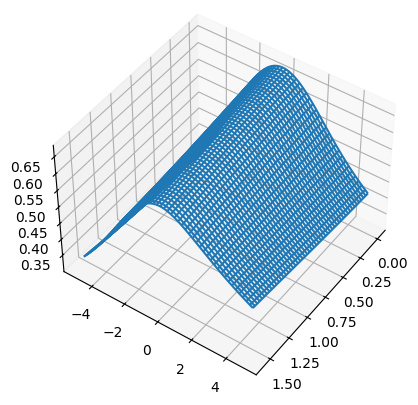

Text(0, 0.5, '|h(t,x)|')

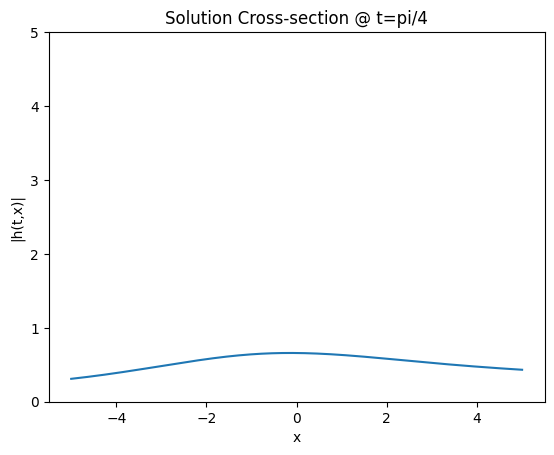

In [13]:
%matplotlib inline

x = np.linspace(-5,5,300)
t = np.linspace(0,math.pi/2,300)

X,T = np.meshgrid(x,t)

_X = torch.tensor(np.dstack((X,T))).float().to(device)

h_r_hat, h_i_hat = model(_X)
h_r_hat = h_r_hat.to('cpu').detach()#.numpy()
h_i_hat = h_i_hat.to('cpu').detach()#.numpy()

h_hat = torch.cat((h_r_hat, h_i_hat),2)


h_norm = np.sqrt((h_hat[:,:,0] ** 2) + (h_hat[:,:,1] ** 2))

fig = plt.figure(figsize=(16, 2))
ax = plt.axes()

cf = ax.contourf(T,X,h_norm, 30)
plt.colorbar(cf)

plt.title('PDE Sol |h(x,t)|')
plt.ylabel("Position (x)")
plt.xlabel("Time (t)")
plt.show()

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_wireframe(T, X, h_norm, cmap='binary')
ax.view_init(45, 35)
plt.show()

x_slice = x[:]
h_slice = h_norm[100,:]

plt.ylim(0,5)

plt.plot(x_slice,h_slice)
plt.title('Solution Cross-section @ t=pi/4')
plt.xlabel('x')
plt.ylabel('|h(t,x)|')